In [1]:
import jax

#jax.config.update("jax_enable_x64", True)
#jax.config.update("jax_debug_nans", True)

import pickle
import datagen
import pandas as pd
import numpy as np
import jax.numpy as jnp
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm import tqdm
from time import time
from functools import partial
from rebayes_mini import callbacks
from bayes_opt import BayesianOptimization
from rebayes_mini.methods import student_t_filter as stf
from rebayes_mini.methods import gauss_filter as kf
from rebayes_mini.methods import robust_filter as rkf
#from rebayes_mini.methods import generalised_bayes_filter as gbf

In [2]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

plt.rcParams["font.size"] = 18
cmap = {
    "KF-IW": "crimson",
    "KF": "lightseagreen",
    "WoLF-IMQ": "dodgerblue",
    "WoLF-MD": "gold",
    "KF-B": "darkorange",
    "KF-PrO": "mediumorchid",
}

In [3]:
delta = 0.1
dynamics_covariance = 0.1
obs_covariance = 10.0
B1 = jnp.array([0, 0, 0, 0])
B2 = jnp.array([-1.225, -0.35, 1.225, 0.35])
B3 = jnp.array([1.225, 0.35,  -1.225,  -0.35])
B = jnp.stack([B1, B2, B3], axis=1)

In [18]:
B.shape

(4, 3)

In [4]:
#name_dgen = "irregular_grid"
#name_dgen = "student_dynamic"
#name_dgen = "student_obs"
#name_dgen = "well_specified"
name_dgen = "maneuver"

match name_dgen:
    case "student_obs":
        dgen = datagen.GaussStMovingObject2D(
            delta, dynamics_covariance, obs_covariance,
            dof_observed=2.01
        )
    case "mean":
        dgen = datagen.GaussMeanOutlierMovingObject2D(
            delta, dynamics_covariance, obs_covariance,
            outlier_proba=0.05,
            outlier_scale=2.0,
        )
    case "added_mean":
        dgen = datagen.GaussOneSideOutlierMovingObject2D(
            delta, dynamics_covariance, obs_covariance,
            outlier_proba=0.05,
            outlier_minval=-100,
            outlier_maxval=100
        )
    case "irregular_grid":
        dgen = datagen.MovingObject2DIrregular(
            delta, dynamics_covariance, obs_covariance,
        )
    case "well_specified":
        dgen = datagen.MovingObject2D(
            delta, dynamics_covariance, obs_covariance,
        )
    case "student_dynamic":
        dgen = datagen.GaussStMovingObject2D_dynamic(
            delta, dynamics_covariance, obs_covariance,
            dof_observed=3.0,
        )
    case "maneuver":
        dgen = datagen.Maneuvering2D(
            delta, dynamics_covariance, obs_covariance, B=B, transition_prob=0.95,
        )
    case _:
        raise ValueError(f"Dgen {name_dgen} not valid")

key = jax.random.PRNGKey(314)
initial_mean = jnp.array([0.0, 0.0, 1.0, 1.0])

if name_dgen == "maneuver":
    initial_mean = (initial_mean, int(0))

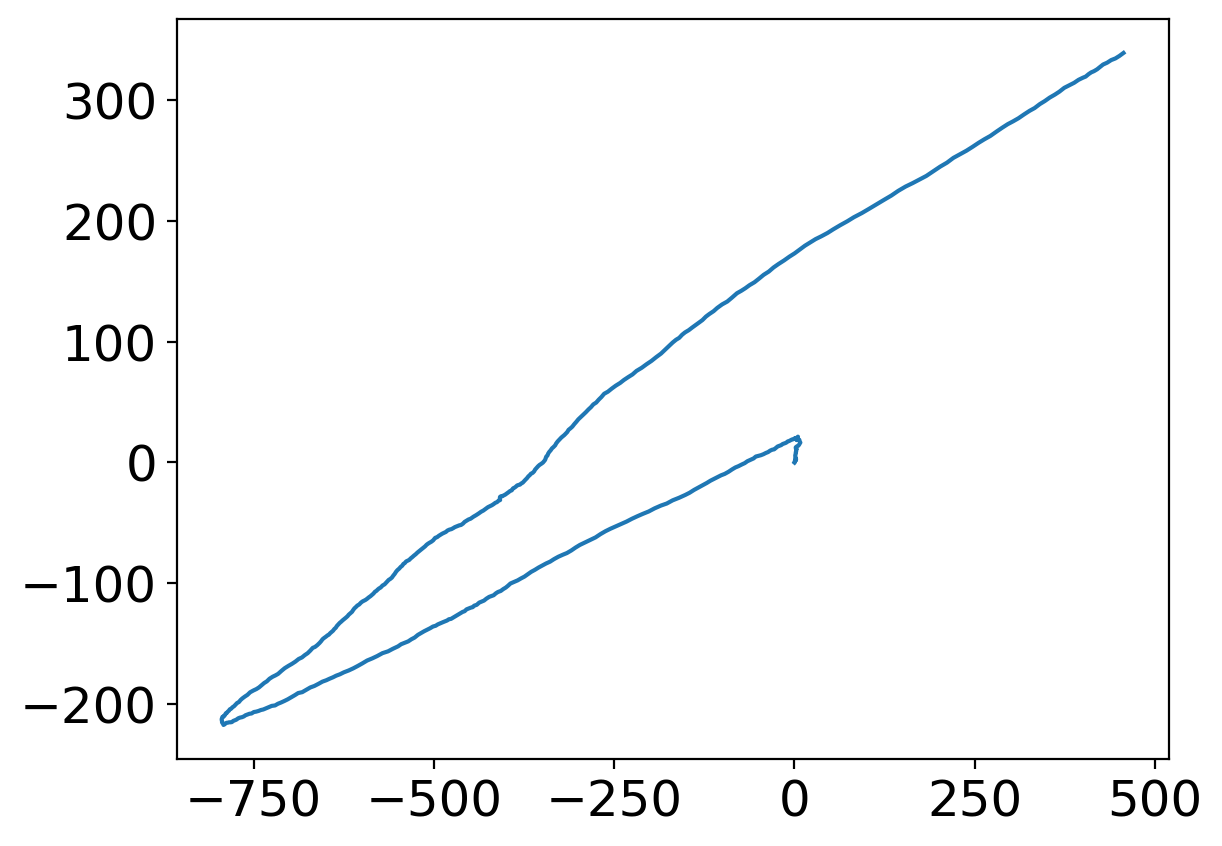

In [5]:
n_steps = 600
n_samples = 1
keys = jax.random.split(key, n_samples)

colors = plt.cm.viridis(jnp.linspace(0, 1, n_samples))
datasets = jax.vmap(dgen.sample, in_axes=(0, None, None))(keys, initial_mean, n_steps)

yv = datasets["observed"]
statev = datasets["latent"]
state = statev[0].squeeze()
label = statev[1].squeeze()
y = yv.squeeze()

plt.plot(state[:, 0], state[:, 1])


In [6]:
def latent_fn(z):
    return dgen.transition_matrix @ z

def measurement_fn(z, _):
    return dgen.projection_matrix @ z
    
@jax.jit
def filter_kf(measurements, state):
    nsteps = len(measurements)
    agent_imq = rkf.ExtendedKalmanFilterIMQ(
        latent_fn, measurement_fn,
        dynamics_covariance=dgen.dynamics_covariance,
        observation_covariance=dgen.observation_covariance,
        soft_threshold=1e8,
    )
    
    init_bel = agent_imq.init_bel(initial_mean[0], cov=1.0)
    filterfn = partial(agent_imq.scan, callback_fn=callbacks.get_updated_mean)
    _, hist = filterfn(init_bel, measurements, jnp.ones(n_steps))

    err = jnp.sqrt(jnp.power(hist - state, 2).sum(axis=0))
    return err, hist

In [7]:
_, run = filter_kf(y, state)
err = jnp.sqrt(jnp.sum(jnp.square(run - state)[:, :2], -1))

In [8]:
from profilter import PrOFilter

@jax.jit
def filter_prokf(n_inner, n_outer, measurements, state):
    nsteps = len(measurements)
    agent_pro = PrOFilter(
        latent_fn, measurement_fn,
        dynamics_covariance=dgen.dynamics_covariance,
        observation_covariance=dgen.observation_covariance,
        n_inner=n_inner,
        n_outer=n_outer
    )
    
    init_bel = agent_pro.init_bel(initial_mean[0], cov=1.0)
    filterfn = partial(agent_pro.scan, callback_fn=callbacks.get_updated_mean)
    _, hist = filterfn(init_bel, measurements, jnp.ones(n_steps))

    err = jnp.sqrt(jnp.power(hist - state, 2)[:, :2].sum(axis=0))
    return err, hist

In [9]:
_, run_pro = filter_prokf(50, 50, y, state)
err_pro = jnp.sqrt(jnp.sum(jnp.square(run_pro - state)[:, :2], -1))

In [10]:
@jax.jit
def filter_wlfmd(threshold, measurements, state):
    agent = rkf.ExtendedKalmanFilterMD(
        latent_fn, measurement_fn,
        dynamics_covariance=dgen.dynamics_covariance,
        observation_covariance=dgen.observation_covariance,
        threshold=threshold
    )
    
    init_bel = agent.init_bel(initial_mean[0], cov=1.0)
    
    _, hist = agent.scan(
        init_bel, measurements, jnp.ones(n_steps), callback_fn=callbacks.get_updated_mean
    )

    err = jnp.sqrt(jnp.power(hist - state, 2)[:, :2].sum(axis=0))
    return err, hist


@jax.jit
def bo_filter_wlfmd(threshold):
    err, _ = filter_wlfmd(threshold, yv[0], statev[0])
    return -err.max()

In [11]:
bo = BayesianOptimization(
    bo_filter_wlfmd,
    pbounds={
        "threshold": (1e-6, 20)
    },
    random_state=314,
    verbose=1
)
bo.maximize(init_points=50, n_iter=50)

|   iter    |  target   | threshold |
-------------------------------------
| 13        | -0.552546 | 2.4458282 |
| 55        | -0.550803 | 0.4038627 |


In [12]:
method = "WoLF-MD"
threshold = bo.max["params"]["threshold"]
#configs[method] = bo.max["params"]

_, run_wlf = filter_wlfmd(threshold, y, state)

err_wlf = jnp.sqrt(jnp.sum(jnp.square(run_wlf - state)[:, :2], -1))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


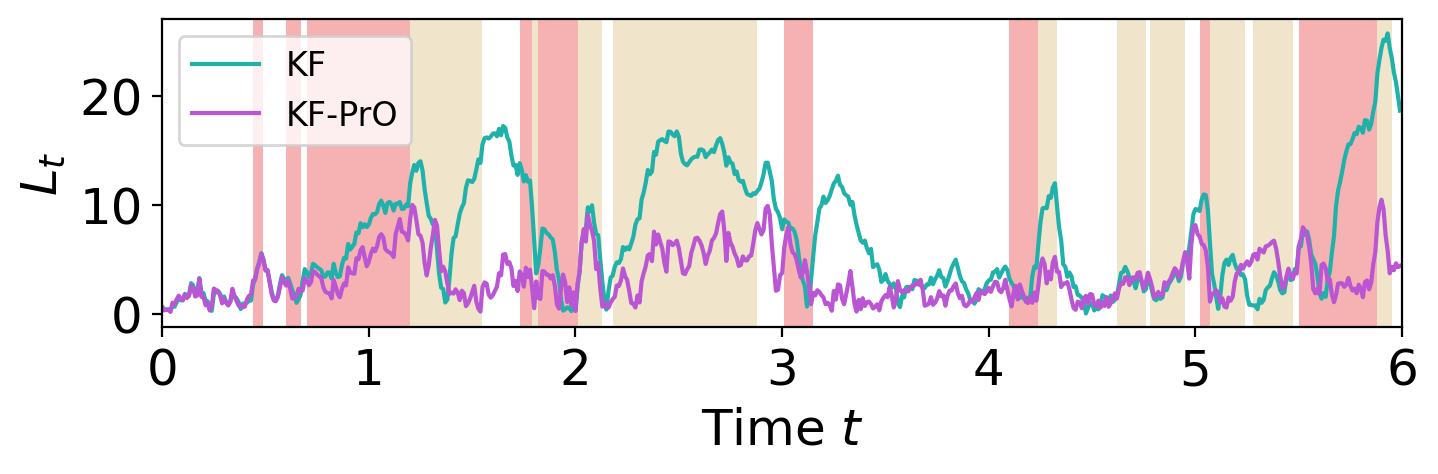

In [17]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

delta = 0.01
n_steps = err.shape[0]
ts = jnp.arange(n_steps) * delta

plt.rcParams["font.size"] = 18
cmap = {
    "KF-IW": "crimson",
    "KF": "lightseagreen",
    "WoLF-IMQ": "dodgerblue",
    "WoLF-MD": "gold",
    "KF-B": "darkorange",
    "KF-PrO": "mediumorchid",
}

import numpy as np
import matplotlib.pyplot as plt

colors = {
    0: "white",
    1: "#E6D3A7",
    2: "lightcoral",
}

fig, ax = plt.subplots(figsize=(8, 2))

for i, value in enumerate(np.array(label)):
    ax.axvspan(i * delta, (i + 1) * delta, color=colors[value], alpha=0.6, linewidth=0)

ax.set_xlim(0, len(label) * delta)
ax.set_ylabel(r"$L_t$")
ax.set_xlabel(r"Time $t$")
plt.plot(ts, err, c=cmap['KF'], label="KF")
plt.plot(ts, err_pro, c=cmap['KF-PrO'], label="KF-PrO")
plt.legend(fontsize=12)
plt.savefig("error_plot.pdf", bbox_inches='tight')